# Hypo3 Time Lag: BTC-GPU and SOXX-RAM

목적: 현재시점 분석에서 상대적으로 신호가 남은 두 관계만 골라 1~8주 lag를 검정한다.

- 대상 관계: `BTC → GPU`, `SOXX → RAM`
- lag 범위: 1~8주
- 설명변수와 통제변수는 모두 같은 lag로 이동한다.
- `SOXX`는 넓은 반도체/AI 수요 proxy이므로 BTC-GPU 회귀에서 `SOXX`를 통제한다.
- hardware 자기시차, 분기 더미, 불필요한 pooled model은 사용하지 않는다.
- 통계 위험요소는 필요한 수준만 저장: HAC 표준오차, VIF, BH 보정 q-value, residual test
- 저장 파일 최소화: 결과 CSV 2개, plot 3개


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt

out = Path("outputs/hypo3_time_lag")
pic = Path("output_pic/hypo3_time_lag")
out.mkdir(parents=True, exist_ok=True)
pic.mkdir(parents=True, exist_ok=True)

p = Path("outputs/hypo3_relation/data.csv")
if not p.exists():
    p = Path("data.csv")

lags = range(1, 9)

plt.rcParams["axes.unicode_minus"] = False


def save(name):
    fp = pic / name
    plt.savefig(fp, dpi=300, bbox_inches="tight")
    print("saved:", fp)


def vif(d, xs):
    X = sm.add_constant(d[xs])
    v = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
    return max(v)


def bh(pv):
    p = np.asarray(pv, dtype=float)
    n = len(p)
    q = np.empty(n)
    order = np.argsort(p)
    best = 1.0
    for i in range(n - 1, -1, -1):
        j = order[i]
        best = min(best, p[j] * n / (i + 1))
        q[j] = min(best, 1.0)
    return q


## 1. Load current macro-hardware dataset

`Hypo3_relation.ipynb`에서 저장한 `data.csv`를 그대로 사용한다. 새로 macro 데이터를 다운로드하지 않는다.


In [2]:
df = pd.read_csv(p)
df = df.rename(columns={df.columns[0]: "date"})
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

need = [
    "gpu_ret", "ram_ret",
    "btc_ret_z", "soxx_ret_z", "fx_ret_z",
]
df = df[need].copy()

display(df.head())
print("loaded:", p)
print("shape:", df.shape)


,gpu_ret,ram_ret,btc_ret_z,soxx_ret_z,fx_ret_z
date,,,,,
2024-03-03,NaN,NaN,3.135861,1.314926,0.441332
2024-03-10,0.002189,0.002896,1.174643,0.048449,-1.063889
2024-03-17,0.003092,0.001473,-0.043514,-0.990617,-0.055229
2024-03-24,0.002050,-0.003016,-0.166595,0.571581,0.765660
2024-03-31,0.001093,-0.001508,0.893986,-0.049618,0.916157


loaded: outputs\hypo3_relation\data.csv
shape: (110, 5)


## 2. Model setting

각 lag에서 종속변수는 현재 주차 hardware return이고, 설명변수와 통제변수는 모두 `k`주 전 값으로 맞춘다.

- `BTC → GPU`: `gpu_ret_t ~ btc_ret_{t-k} + fx_ret_{t-k} + soxx_ret_{t-k}`
- `SOXX → RAM`: `ram_ret_t ~ soxx_ret_{t-k} + fx_ret_{t-k} + btc_ret_{t-k}`

`SOXX`는 넓은 반도체/AI 수요 proxy이므로 BTC-GPU에서도 `SOXX`를 통제한다.


In [3]:
spec = {
    "BTC-GPU": {
        "y": "gpu_ret",
        "x": "btc_ret_z",
        "ctrl": ["fx_ret_z", "soxx_ret_z"],
    },
    "SOXX-RAM": {
        "y": "ram_ret",
        "x": "soxx_ret_z",
        "ctrl": ["fx_ret_z", "btc_ret_z"],
    },
}

pd.DataFrame([
    {"pair": k, "y": v["y"], "x": v["x"], "ctrl": ", ".join(v["ctrl"])}
    for k, v in spec.items()
])


,pair,y,x,ctrl
0,BTC-GPU,gpu_ret,btc_ret_z,"fx_ret_z, soxx_ret_z"
1,SOXX-RAM,ram_ret,soxx_ret_z,"fx_ret_z, btc_ret_z"


## 3. Run lag regressions

저장하는 진단값은 다음만 포함한다.

- `coef`, `p`: lagged factor의 방향과 유의성
- `q`: 16개 검정에 대한 BH 보정 p-value
- `pr2`: target factor가 controls 이후 추가로 설명하는 partial R²
- `max_vif`: 다중공선성 점검
- `lb_p`, `bp_p`: 잔차 자기상관/이분산 위험 점검
- `dir_acc`: 통제 후 residualized direction 기준의 부호 적중률


In [4]:
def part(d, y, x, cs):
    yr = sm.OLS(d[y], sm.add_constant(d[cs])).fit().resid
    xr = sm.OLS(d[x], sm.add_constant(d[cs])).fit().resid
    return xr, yr


def run(pair, k):
    s = spec[pair]
    y, x, cs = s["y"], s["x"], s["ctrl"]

    d = pd.DataFrame({y: df[y]})
    xs = []
    for v in [x] + cs:
        nm = v.replace("_ret_z", "").replace("_z", "") + f"_l{k}"
        d[nm] = df[v].shift(k)
        xs.append(nm)

    xk = xs[0]
    ck = xs[1:]
    d = d.dropna()

    X = sm.add_constant(d[xs])
    m = sm.OLS(d[y], X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
    r = sm.OLS(d[y], sm.add_constant(d[ck])).fit()
    pr2 = (m.rsquared - r.rsquared) / (1 - r.rsquared)

    xr, yr = part(d, y, xk, ck)
    pred = np.sign(m.params[xk] * xr)
    real = np.sign(yr)
    ok = (pred != 0) & (real != 0)
    acc = float((pred[ok] == real[ok]).mean())

    lb = acorr_ljungbox(m.resid, lags=[4], return_df=True)["lb_pvalue"].iloc[0]
    bp = het_breuschpagan(m.resid, m.model.exog)[1]

    return {
        "pair": pair,
        "lag": k,
        "n": int(m.nobs),
        "coef": m.params[xk],
        "se": m.bse[xk],
        "t": m.tvalues[xk],
        "p": m.pvalues[xk],
        "r2": m.rsquared,
        "pr2": pr2,
        "max_vif": vif(d, xs),
        "dw": durbin_watson(m.resid),
        "lb_p": lb,
        "bp_p": bp,
        "dir_acc": acc,
        "dir": "up" if m.params[xk] > 0 else "down",
        "model": y + " ~ " + " + ".join(xs),
    }

res = pd.DataFrame([run(pair, k) for pair in spec for k in lags])
res["q"] = bh(res["p"])
res["keep"] = (res["q"] < 0.10) & (res["pr2"] >= 0.01) & (res["max_vif"] < 5)

res = res[[
    "pair", "lag", "n", "coef", "se", "t", "p", "q", "r2", "pr2",
    "max_vif", "dw", "lb_p", "bp_p", "dir_acc", "dir", "keep", "model"
]]

top = res[res["keep"]].copy()
if len(top) == 0:
    top = res.sort_values(["pair", "p", "pr2"], ascending=[True, True, False]).groupby("pair").head(2).copy()
else:
    top = top.sort_values(["pair", "q", "p", "pr2"], ascending=[True, True, True, False])

res.to_csv(out / "lag_res.csv", index=False)
top.to_csv(out / "lag_top.csv", index=False)

display(res.round(5))
print("saved:", out / "lag_res.csv", out / "lag_top.csv")


,pair,lag,n,coef,se,t,p,q,r2,pr2,max_vif,dw,lb_p,bp_p,dir_acc,dir,keep,model
0,BTC-GPU,1,105,-0.00108,0.00114,-0.94692,0.34368,0.64536,0.02110,0.01271,1.12375,0.62581,0.0,0.46026,0.50476,down,False,gpu_ret ~ btc_l1 + fx_l1 + soxx_l1
1,BTC-GPU,2,104,-0.00006,0.00040,-0.14717,0.88300,0.92031,0.02162,0.00004,1.12673,0.61739,0.0,0.32832,0.50962,down,False,gpu_ret ~ btc_l2 + fx_l2 + soxx_l2
2,BTC-GPU,3,103,-0.00024,0.00037,-0.63177,0.52754,0.66157,0.01358,0.00059,1.13540,0.61070,0.0,0.70674,0.45631,down,False,gpu_ret ~ btc_l3 + fx_l3 + soxx_l3
3,BTC-GPU,4,102,0.00030,0.00049,0.61656,0.53753,0.66157,0.00873,0.00098,1.12583,0.58627,0.0,0.61041,0.45098,up,False,gpu_ret ~ btc_l4 + fx_l4 + soxx_l4
4,BTC-GPU,5,101,0.00054,0.00059,0.90963,0.36302,0.64536,0.01592,0.00305,1.13022,0.56086,0.0,0.34255,0.53465,up,False,gpu_ret ~ btc_l5 + fx_l5 + soxx_l5
5,BTC-GPU,6,100,0.00043,0.00057,0.75743,0.44879,0.66157,0.00882,0.00198,1.12758,0.56417,0.0,0.98590,0.55000,up,False,gpu_ret ~ btc_l6 + fx_l6 + soxx_l6
6,BTC-GPU,7,99,0.00006,0.00062,0.10005,0.92031,0.92031,0.00176,0.00004,1.12816,0.59037,0.0,0.99223,0.43434,up,False,gpu_ret ~ btc_l7 + fx_l7 + soxx_l7
7,BTC-GPU,8,98,0.00011,0.00073,0.14595,0.88396,0.92031,0.02402,0.00011,1.14615,0.62360,0.0,0.50072,0.57143,up,False,gpu_ret ~ btc_l8 + fx_l8 + soxx_l8
8,SOXX-RAM,1,105,0.00318,0.00205,1.55410,0.12016,0.43728,0.03625,0.01565,1.12375,0.66760,0.0,0.38826,0.54286,up,False,ram_ret ~ soxx_l1 + fx_l1 + btc_l1
9,SOXX-RAM,2,104,0.00339,0.00273,1.24418,0.21343,0.48785,0.02996,0.01759,1.12673,0.65352,0.0,0.21639,0.54808,up,False,ram_ret ~ soxx_l2 + fx_l2 + btc_l2


saved: outputs\hypo3_time_lag\lag_res.csv outputs\hypo3_time_lag\lag_top.csv


## 4. Plots

필요한 그림만 저장한다.

1. lag별 계수와 HAC 95% CI
2. lag별 partial R²
3. 선택된 lag의 통제 후 residualized scatter


saved: output_pic\hypo3_time_lag\01_coef.png


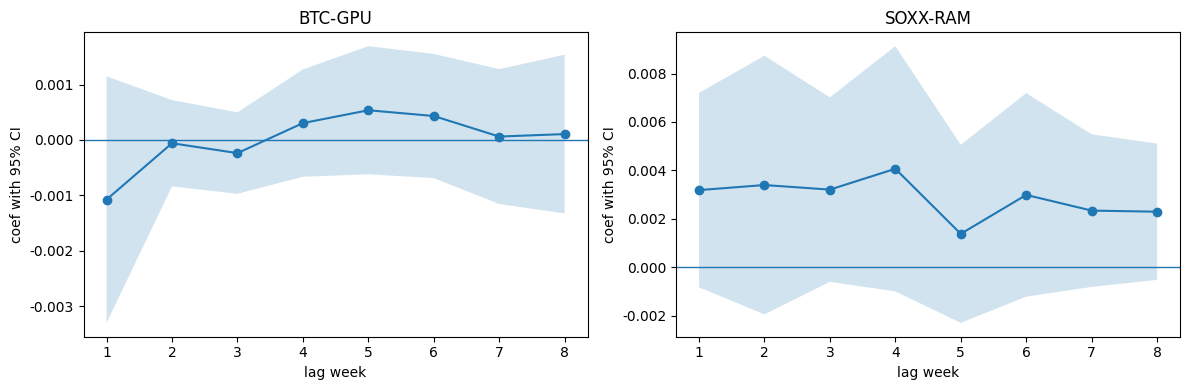

saved: output_pic\hypo3_time_lag\02_pr2.png


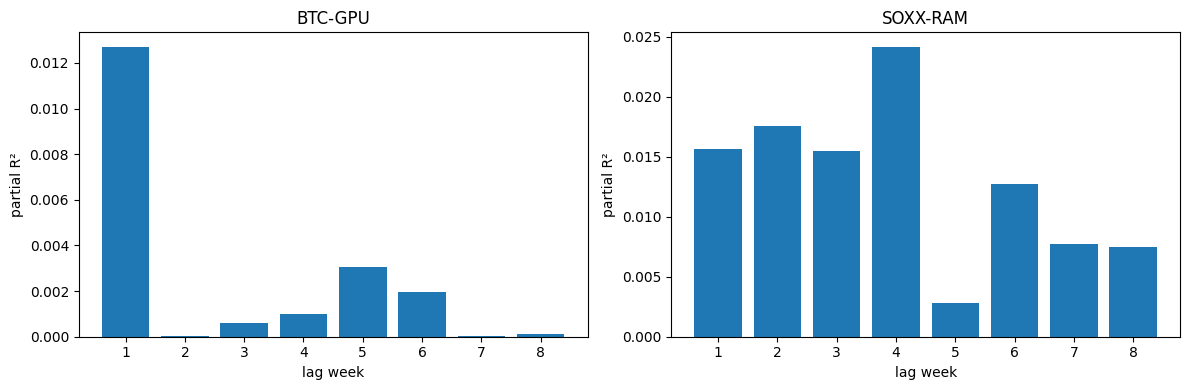

In [5]:
# 1) coefficient path with HAC CI
fig0, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for i, pair in enumerate(spec):
    d = res[res["pair"] == pair].copy()
    lo = d["coef"] - 1.96 * d["se"]
    hi = d["coef"] + 1.96 * d["se"]
    ax[i].plot(d["lag"], d["coef"], marker="o")
    ax[i].fill_between(d["lag"], lo, hi, alpha=0.2)
    ax[i].axhline(0, linewidth=1)
    ax[i].set_title(pair)
    ax[i].set_xlabel("lag week")
    ax[i].set_ylabel("coef with 95% CI")
    ax[i].set_xticks(list(lags))
plt.tight_layout()
save("01_coef.png")
plt.show()

# 2) partial R2 path
fig0, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for i, pair in enumerate(spec):
    d = res[res["pair"] == pair].copy()
    ax[i].bar(d["lag"], d["pr2"])
    ax[i].set_title(pair)
    ax[i].set_xlabel("lag week")
    ax[i].set_ylabel("partial R²")
    ax[i].set_xticks(list(lags))
plt.tight_layout()
save("02_pr2.png")
plt.show()


saved: output_pic\hypo3_time_lag\03_top.png


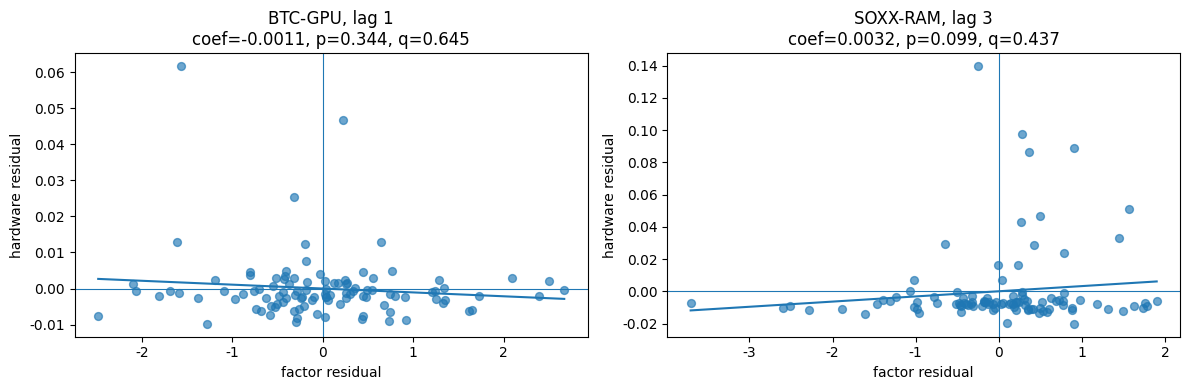

In [6]:
# 3) residualized scatter for selected lags
best = top.sort_values(["pair", "p", "pr2"], ascending=[True, True, False]).groupby("pair").head(1)
fig0, ax = plt.subplots(1, len(best), figsize=(6 * len(best), 4))
if len(best) == 1:
    ax = [ax]

for a, (_, row) in zip(ax, best.iterrows()):
    pair = row["pair"]
    k = int(row["lag"])
    s = spec[pair]
    y, x, cs = s["y"], s["x"], s["ctrl"]

    d = pd.DataFrame({y: df[y]})
    xs = []
    for v in [x] + cs:
        nm = v.replace("_ret_z", "").replace("_z", "") + f"_l{k}"
        d[nm] = df[v].shift(k)
        xs.append(nm)
    d = d.dropna()

    xr, yr = part(d, y, xs[0], xs[1:])
    a.scatter(xr, yr, s=32, alpha=0.65)
    b1, b0 = np.polyfit(xr, yr, 1)
    xx = np.linspace(xr.min(), xr.max(), 50)
    a.plot(xx, b1 * xx + b0, linewidth=1.5)
    a.axhline(0, linewidth=0.8)
    a.axvline(0, linewidth=0.8)
    a.set_title(f"{pair}, lag {k}\ncoef={row.coef:.4f}, p={row.p:.3f}, q={row.q:.3f}")
    a.set_xlabel("factor residual")
    a.set_ylabel("hardware residual")

plt.tight_layout()
save("03_top.png")
plt.show()


## 5. Quick audit

저장 파일 개수와 핵심 설정만 확인한다. 추가 파일은 만들지 않는다.


In [ ]:
print("csv:", sorted(p.name for p in out.glob("*.csv")))
print("png:", sorted(p.name for p in pic.glob("*.png")))
print("pairs:", list(spec.keys()))
print("lags:", list(lags))
print("SOXX is used as broad semiconductor/AI proxy; single-stock proxy is not used")
print("no quarter dummy, no hardware autoregressive regressor, no pooled model")
